In [47]:
import tarfile
import urllib.request
from pathlib import Path
import pandas as pd

In [48]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))


In [49]:
housing = load_housing_data()
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [50]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [51]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [52]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [53]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [54]:
import copy

housing_copy = copy.deepcopy(housing)

In [55]:
housing.keys()

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [56]:
requiredColumns = ['housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

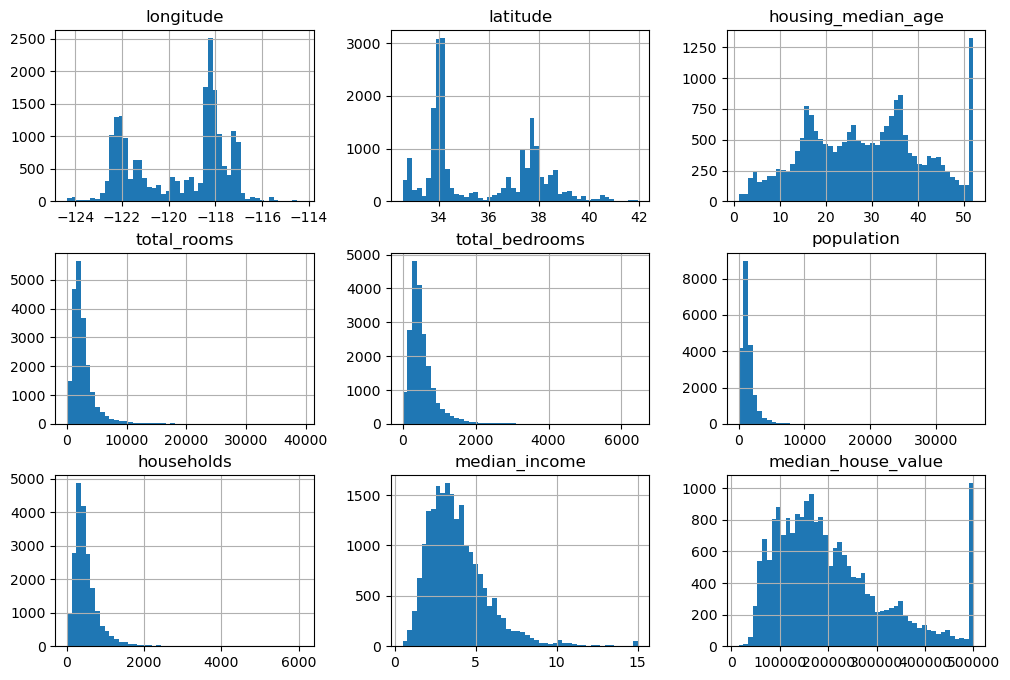

In [57]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(12,8))

### Custom function to split train and test set

In [58]:
import numpy as np
def trainTestSplit(data, testRatio):
    #to keep the same indexes
    np.random.seed(42)
    shuffledIndices = np.random.permutation(len(data))
    testSize = int(len(data)*testRatio)
    trainIndices = shuffledIndices[:testSize]
    testIndices = shuffledIndices[testSize:]
    trainData = data.iloc[trainIndices]
    testData = data.iloc[testIndices]
    return trainData, testData
train_data, test_data = trainTestSplit(housing, 0.2)
print(len(train_data))
print(len(test_data))

4128
16512


In [59]:
train_data.iloc[50]

longitude              -122.42
latitude                 37.72
housing_median_age        42.0
total_rooms             4219.0
total_bedrooms          1125.0
population              3549.0
households               993.0
median_income           1.2387
median_house_value    212800.0
ocean_proximity       NEAR BAY
Name: 19332, dtype: object

#### sklearn.train_test_split to split

In [60]:
from sklearn.model_selection import train_test_split
trainSet, testSet = train_test_split(housing, test_size=0.2, random_state=42)
print(len(trainSet))
print(len(testSet))
print(trainSet.iloc[50])

16512
4128
longitude                -117.18
latitude                   32.76
housing_median_age           8.0
total_rooms               3694.0
total_bedrooms             997.0
population                1297.0
households                 807.0
median_income             3.6492
median_house_value      158900.0
ocean_proximity       NEAR OCEAN
Name: 4420, dtype: object


In [61]:
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0.0, 1.5, 3., 3.5, 5., 6.5, 8., 9.5, 11., np.inf],
                                              labels=[1, 2, 3, 4, 5, 6, 7, 8, 9])

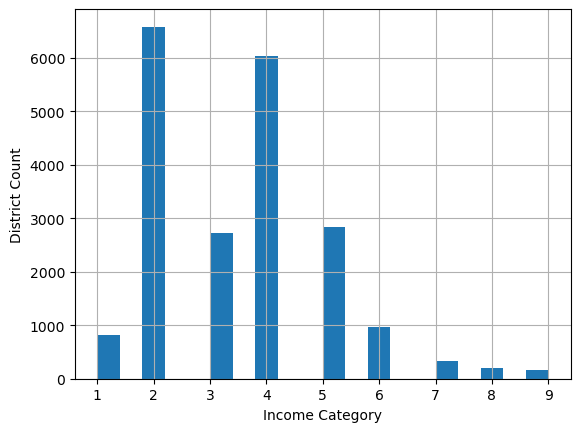

In [62]:
housing['income_cat'].hist(bins=20)
plt.xlabel('Income Category')
plt.ylabel('District Count')
plt.show()

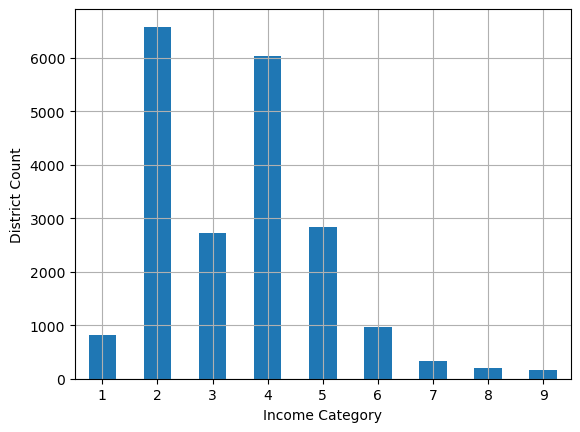

In [63]:
housing['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel('Income Category')
plt.ylabel('District Count')
plt.show()

<h4 style="color:red;"> Stratified Sampling</h4>

In [64]:
from sklearn.model_selection import StratifiedShuffleSplit

In [65]:
splitter = StratifiedShuffleSplit(n_splits=10,test_size=0.2, random_state=42)
stratifiedSample = []
for trainIndex, testIndex in splitter.split(housing, housing['income_cat']):
    strat_train_set_n = housing.iloc[trainIndex]
    strat_test_set_n = housing.iloc[testIndex]
    stratifiedSample.append([strat_train_set_n, strat_test_set_n])

<h4 style="color:teal">Verify frequency in each train and test set for <b>income_cat</b></h4>

In [66]:
overallTrain = pd.concat([t for t,_ in stratifiedSample])
overallTest = pd.concat([t for _, t in stratifiedSample])
pd.DataFrame({
    "Train": overallTrain['income_cat'].value_counts(normalize=True).sort_index() * 100,
    "Test": overallTest['income_cat'].value_counts(normalize=True).sort_index() * 100,
}).round(2)

,Train,Test
income_cat,,
1,3.98,3.97
2,31.89,31.88
3,13.18,13.18
4,29.21,29.19
5,13.74,13.74
6,4.66,4.68
7,1.64,1.65
8,0.94,0.94
9,0.76,0.78


<h5 style="color:teal;">Drop <b>income cat</b> as it is not required anymore</h5>

In [67]:
for t, _ in stratifiedSample:
    t.drop('income_cat', axis=1, inplace=True)
for _, t in stratifiedSample:
    t.drop('income_cat', axis=1, inplace=True)  

/var/folders/x1/vmgj69g51xgbn4fgdlm5lb800000gn/T/ipykernel_11424/3048719420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t.drop('income_cat', axis=1, inplace=True)
/var/folders/x1/vmgj69g51xgbn4fgdlm5lb800000gn/T/ipykernel_11424/3048719420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t.drop('income_cat', axis=1, inplace=True)
/var/folders/x1/vmgj69g51xgbn4fgdlm5lb800000gn/T/ipykernel_11424/3048719420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

<h5 style="color:teal">Using sklearn.train_test_split to perform stratified sampling</h5>

In [68]:
strat_train_set, strat_test_set = train_test_split(housing, train_size=0.8, random_state=42, stratify=housing['income_cat'])
housing_train = strat_train_set.copy()

<h4 style="color:purple">Visualization</h4>

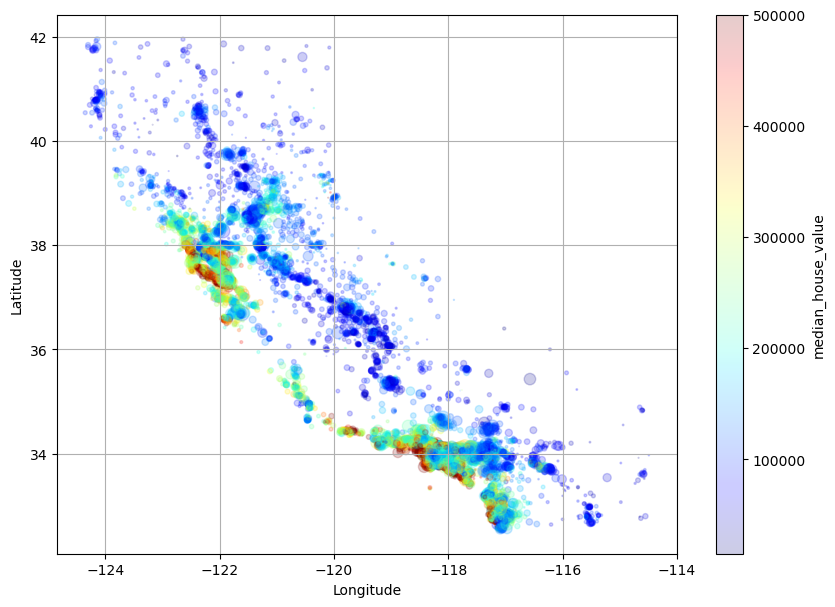

In [69]:
housing_train.plot(kind='scatter', x='longitude', y='latitude', alpha=0.2, grid=True, 
                   cmap='jet', s=housing_train['population']/100, c='median_house_value',
                   colorbar=True, legend=True, sharex=False,figsize=(10,7))
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<h5 style="color:teal">Finding pearsons correlation</h5>

In [70]:
corr_matrix = housing_train[requiredColumns].corr()
corr_matrix['median_house_value']

housing_median_age    0.104579
total_rooms           0.137682
total_bedrooms        0.050584
population           -0.024186
households            0.067328
median_income         0.689881
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [71]:
print(housing_copy.head(2))
housing_train['households_per_room'] = housing_train['total_rooms']/housing_train['households']
housing_train['population_per_room'] = housing_train['total_rooms']/housing_train['population']
requiredColumns.append('households_per_room')
requiredColumns.append('population_per_room')


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  


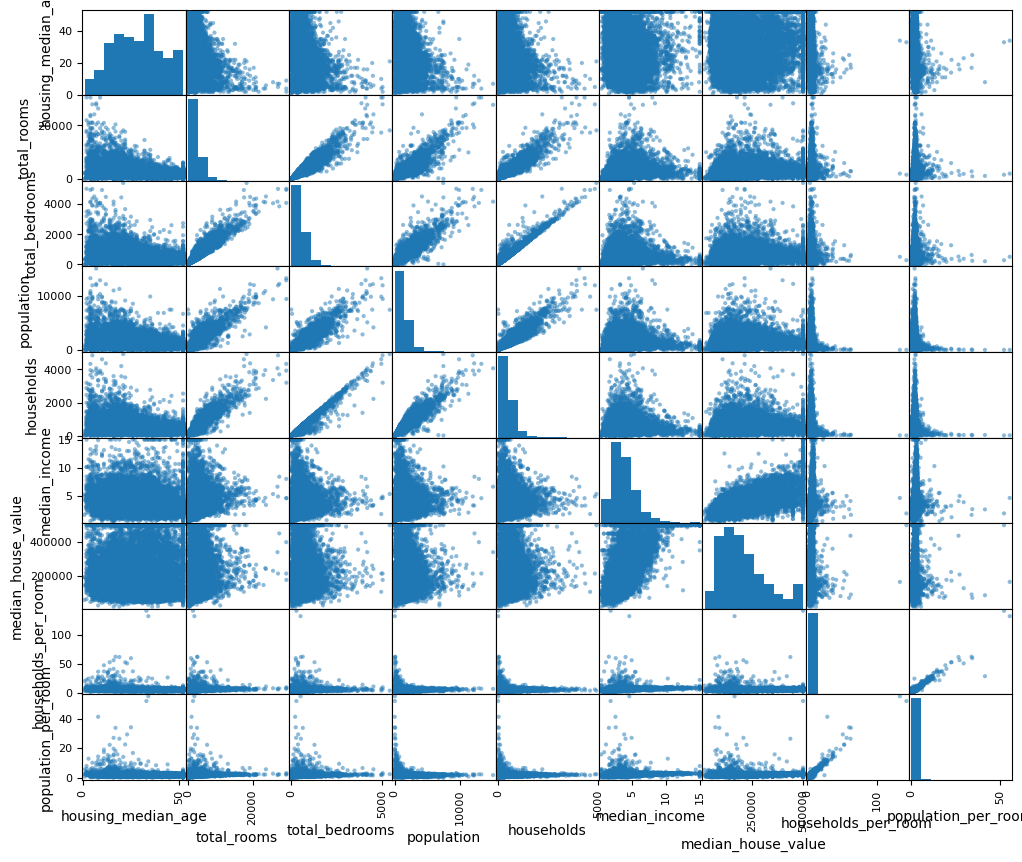

In [72]:
from pandas.plotting import scatter_matrix
scatter_matrix(housing_train[requiredColumns], figsize=(12,10))
plt.show()

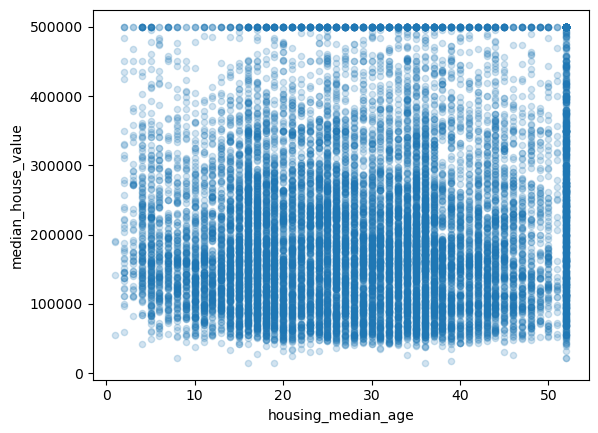

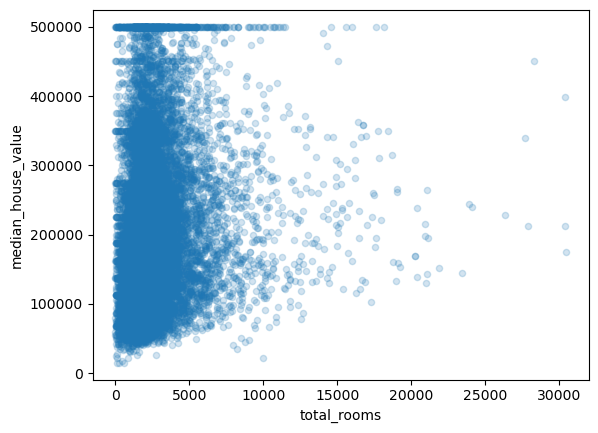

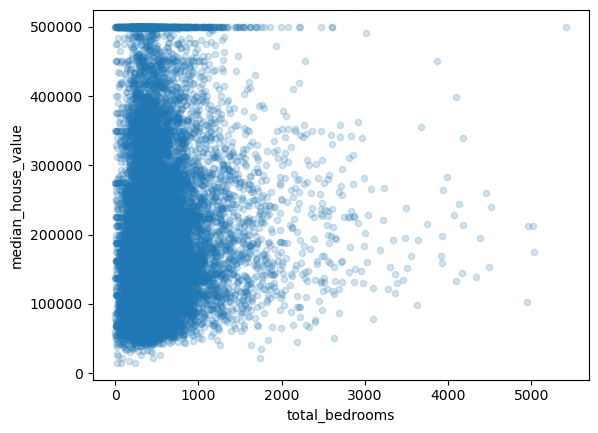

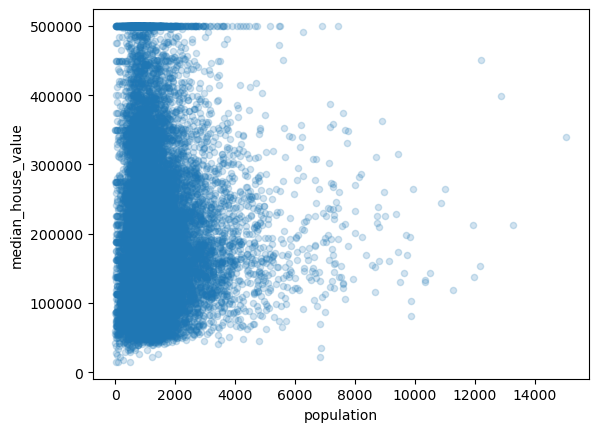

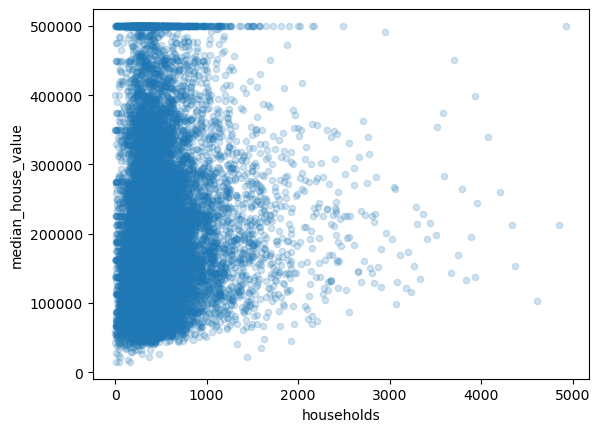

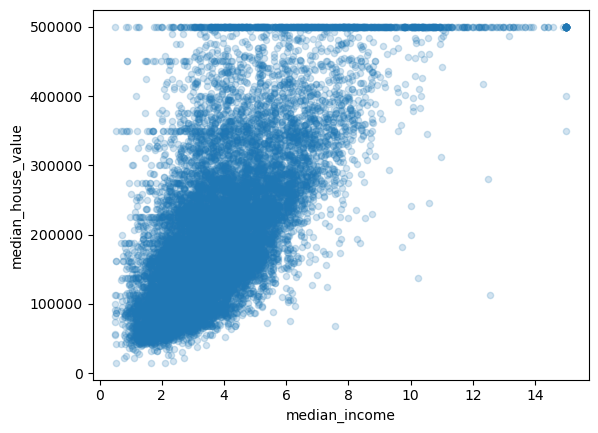

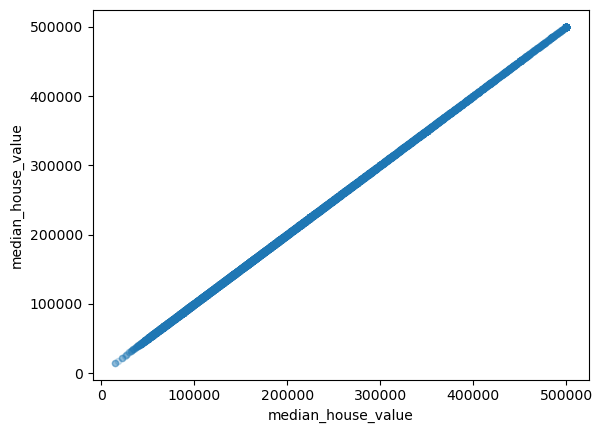

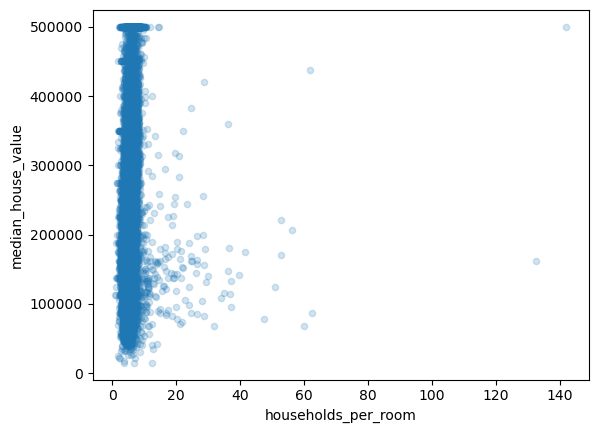

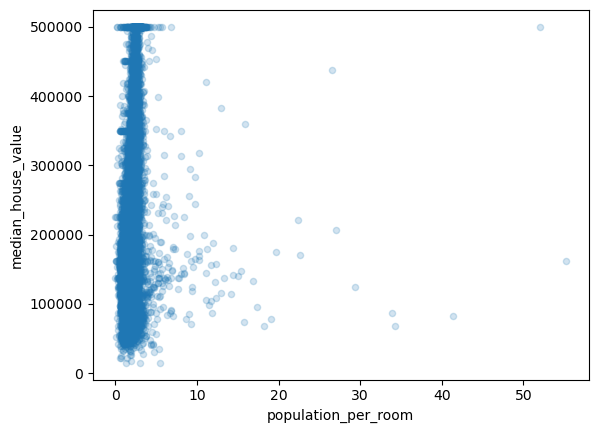

In [73]:
for label in requiredColumns:
    housing_train.plot(y='median_house_value', x=label, kind='scatter', alpha=0.2)
    plt.show()

In [74]:
housing_train['bedroom_ratio'] = housing_train['total_bedrooms']/housing_train['total_rooms']
requiredColumns.append('bedroom_ratio')
corr_matrix_2 = housing_train[requiredColumns].corr()
corr_matrix_2['median_house_value']

housing_median_age     0.104579
total_rooms            0.137682
total_bedrooms         0.050584
population            -0.024186
households             0.067328
median_income          0.689881
median_house_value     1.000000
households_per_room    0.142805
population_per_room    0.197299
bedroom_ratio         -0.257677
Name: median_house_value, dtype: float64

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


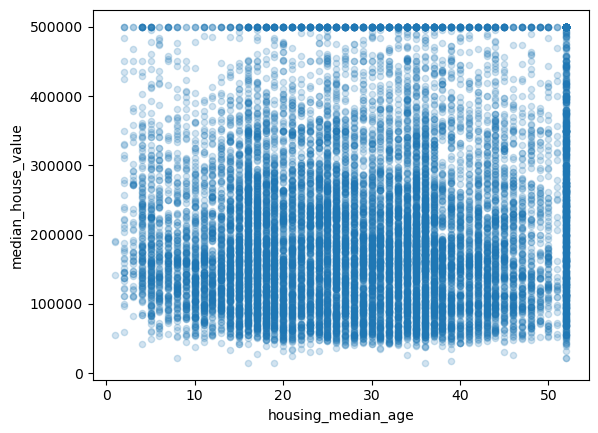

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


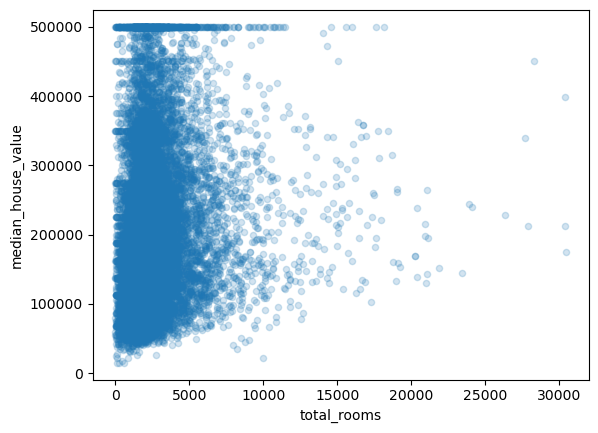

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


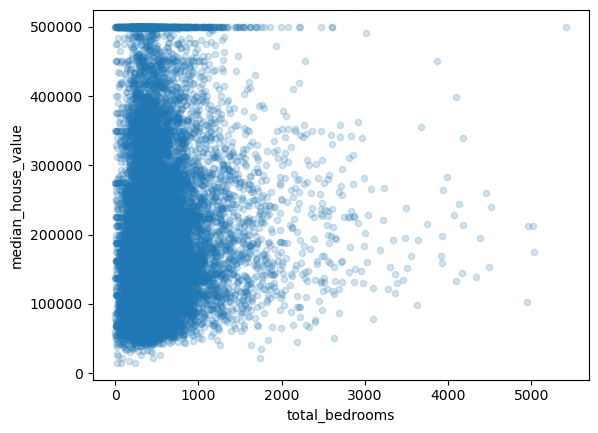

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


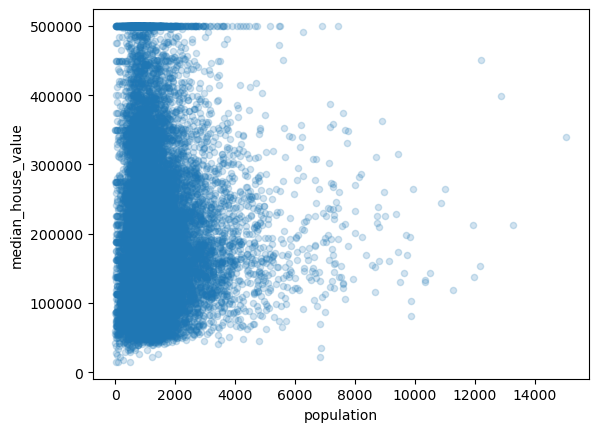

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


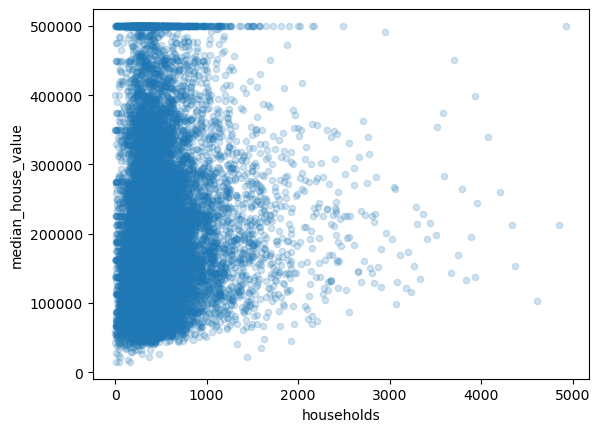

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


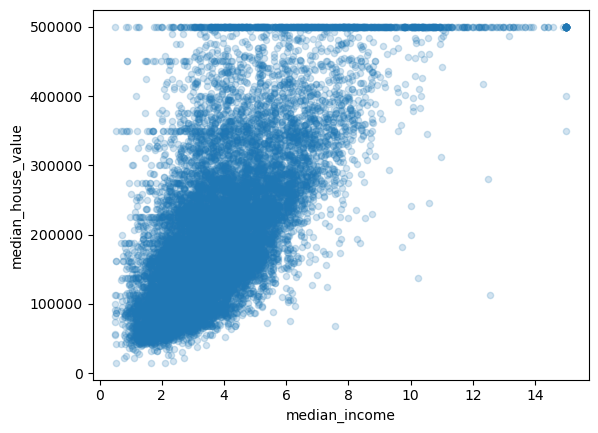

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


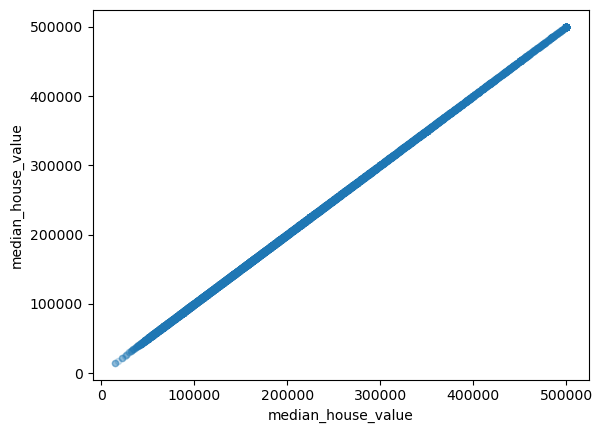

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


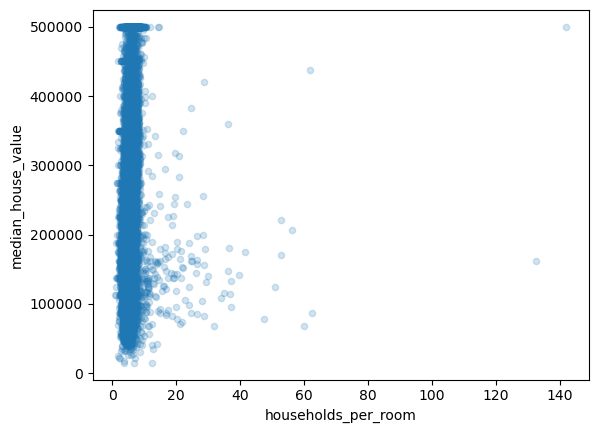

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


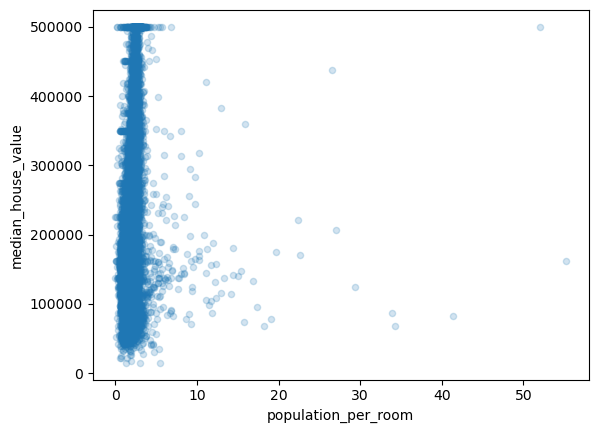

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


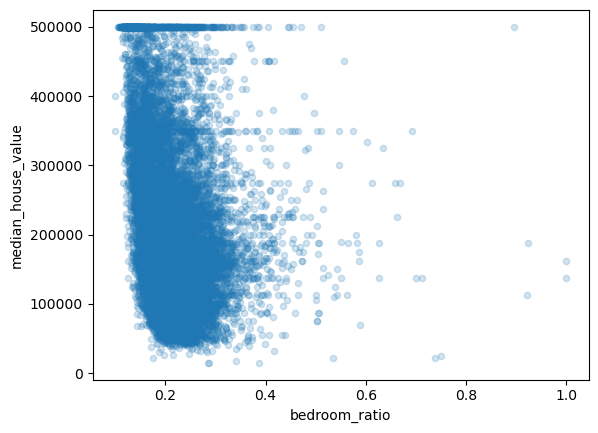

In [75]:
for label in requiredColumns:
    housing_train.plot(y='median_house_value', x=label, kind='scatter', alpha=0.2,cmap='jet')
    plt.show()

In [76]:
npArray = np.array(housing)
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,7
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,7
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,6
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,2
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,2
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,2


In [77]:
ocean_proximity = pd.Series(housing['ocean_proximity'])
ocean_proximity

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: object

In [78]:
ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [79]:
ocean_proximity.isnull().sum()

0

In [ ]:
ocean_proximity_array = np.array(ocean_proximity)
value, counts = np.unique(ocean_proximity_array, return_counts=True)
mode_value = value[np.argmax(counts)]
mode_counts = counts.max()
print(f"Mode Value = {mode_value} and Mode Counts = {mode_counts}, {np.argmax(counts)}")

Mode Value = <1H OCEAN and Mode Counts = 9136, 0
